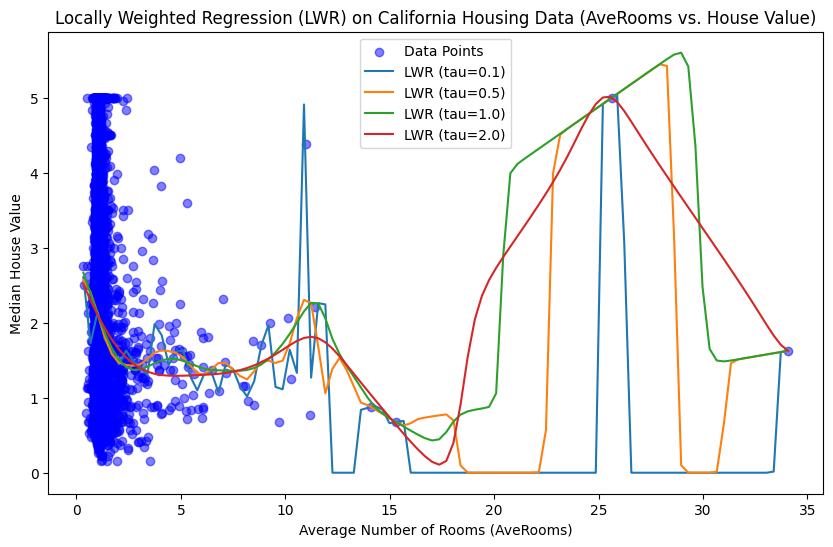

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing


# Step 1: Load the California Housing dataset
california_housing = fetch_california_housing()
X = california_housing.data[:, 3].reshape(-1, 1)  # Use the 'AveRooms' feature (average number of rooms)
y = california_housing.target  # Target variable (median house value)

# Step 2: Define the Locally Weighted Regression function with regularization
def locally_weighted_regression(X_train, y_train, X_test, tau=1.0, epsilon=1e-5):
    m = len(X_train)
    y_pred = np.zeros(len(X_test))

    for i, x in enumerate(X_test):
        x = x[0]  # Extract scalar value from the 2D array
        # Compute the weight matrix (Gaussian kernel)
        weights = np.exp(-np.sum((X_train - x)**2, axis=1) / (2 * tau**2))
        W = np.diag(weights)

        # Solve the weighted least squares problem: (X^T W X + epsilon I) (theta) = (X^T W y)
        X_train_augmented = np.hstack((np.ones((m, 1)), X_train))  # Add bias term (x0 = 1)
        XTX = X_train_augmented.T @ W @ X_train_augmented
        XTX_reg = XTX + epsilon * np.eye(X_train_augmented.shape[1])  # Add regularization term
        theta = np.linalg.inv(XTX_reg) @ (X_train_augmented.T @ W @ y_train)

        # Make the prediction for the test point
        X_test_augmented = np.array([1, x])  # Add bias term (x0 = 1)
        y_pred[i] = X_test_augmented @ theta

    return y_pred

# Step 3: Generate predictions on a range of test values
X_test = np.linspace(min(X), max(X), 100).reshape(-1, 1)

# Step 4: Perform Locally Weighted Regression for different tau values
tau_values = [0.1, 0.5, 1.0, 2.0]
plt.figure(figsize=(10, 6))

# Scatter plot of the original data
plt.scatter(X, y, color='blue', alpha=0.5, label='Data Points')

# Perform LWR and plot for different tau values
for tau in tau_values:
    y_pred = locally_weighted_regression(X, y, X_test, tau)
    plt.plot(X_test, y_pred, label=f'LWR (tau={tau})')

# Step 5: Customize the plot
plt.title("Locally Weighted Regression (LWR) on California Housing Data (AveRooms vs. House Value)")
plt.xlabel("Average Number of Rooms (AveRooms)")
plt.ylabel("Median House Value")
plt.legend()
plt.show()